In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support,accuracy_score,confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
from sklearn.feature_selection import mutual_info_classif, RFE

In [20]:
df = pd.read_csv(r"D:\cse\SEM5\INT234\Project\model_ready.csv")

In [21]:
X = df.drop(columns=['is_productive','is_healthy'], errors='ignore')
y = df['is_productive']    # Linear Regression will treat this as continuous (0/1)
y.value_counts()


is_productive
0    25205
1     4795
Name: count, dtype: int64

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)


LinearRegression()

In [24]:
preds = linreg.predict(X_val)

In [25]:
preds_binary = (preds >= 0.5).astype(int)


In [26]:
auc = roc_auc_score(y_val, preds)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds_binary, average='binary')
metrics = {'model':'Linear_noScaling','auc':auc,'precision':prec,'recall':rec,'f1':f1}




Model: Linear Regression
Accuracy: 0.8628333333333333
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      5041
           1       0.79      0.19      0.31       959

    accuracy                           0.86      6000
   macro avg       0.83      0.59      0.62      6000
weighted avg       0.85      0.86      0.83      6000



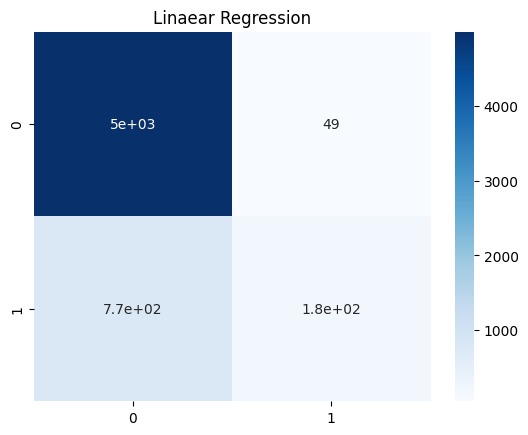

In [27]:
print(f"\nModel: Linear Regression")
print("Accuracy:", accuracy_score(y_val,preds_binary))
print(classification_report(y_val, preds_binary))
sns.heatmap(confusion_matrix(y_val,preds_binary), annot=True, cmap="Blues")
plt.title("Linaear Regression")
plt.show()


In [28]:
joblib.dump(linreg, r'D:\cse\SEM5\INT234\Project\models\logreg_sm_scaler.pkl')

['D:\\cse\\SEM5\\INT234\\Project\\models\\logreg_sm_scaler.pkl']

In [29]:
metrics_df2 = pd.DataFrame([metrics])
metrics_df2.to_csv('D:/cse/SEM5/INT234/Project/results/model_metrics.csv', mode='a', header=False, index=False)

In [30]:
#with scaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

In [31]:
linreg_s = LinearRegression()
linreg_s.fit(X_train_s, y_train)


LinearRegression()

In [32]:
preds_s = linreg_s.predict(X_val_s)
preds_sb = (preds_s >= 0.5).astype(int)

In [33]:
auc = roc_auc_score(y_val, preds_sb)
prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds_sb, average='binary')
metrics_scaled = {'model':'Linear_Scaled','auc':auc,'precision':prec,'recall':rec,'f1':f1}



Model: Linear Regression(Scaled
Accuracy: 0.8628333333333333
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      5041
           1       0.79      0.19      0.31       959

    accuracy                           0.86      6000
   macro avg       0.83      0.59      0.62      6000
weighted avg       0.85      0.86      0.83      6000



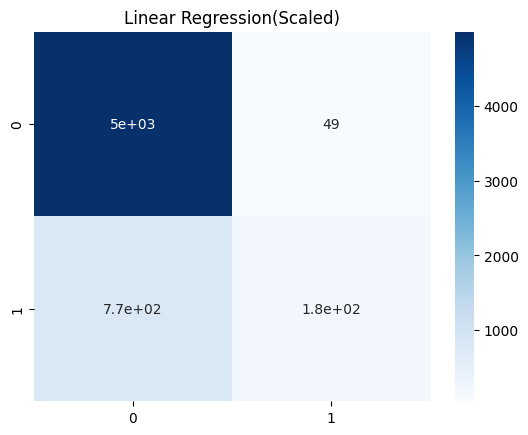

In [34]:
print(f"\nModel: Linear Regression(Scaled")
print("Accuracy:", accuracy_score(y_val,preds_sb))
print(classification_report(y_val, preds_sb))
sns.heatmap(confusion_matrix(y_val,preds_sb), annot=True, cmap="Blues")
plt.title("Linear Regression(Scaled)")
plt.show()


In [35]:
joblib.dump(scaler,  r'D:\cse\SEM5\INT234\Project\models\logreg_sm_scaler.pkl')
joblib.dump(linreg_s, r'D:\cse\SEM5\INT234\Project\models\logreg_sm_scaler.pkl')



['D:\\cse\\SEM5\\INT234\\Project\\models\\logreg_sm_scaler.pkl']

In [36]:
# Append metrics
pd.DataFrame([metrics_scaled]).to_csv( 'D:/cse/SEM5/INT234/Project/results/model_metrics.csv',
    mode='a',
    header=False,
    index=False
)